In [1]:
import os
import glob
import os
import pandas as pd
import numpy as np
import yaml
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
import scipy.sparse as sp
from tqdm import tqdm
from collections import Counter
import time
from scipy.spatial.distance import cdist
import scipy
from scanpy.tools._utils import get_init_pos_from_paga 
import rmm
import cupy
import cudf
import cupy as cp
from cuml.metrics import pairwise_distances
from cuml.metrics import nan_euclidean_distances
from rmm.allocators.cupy import rmm_cupy_allocator
import anndata as an
import scanpy as sc
import rapids_singlecell as rsc
import scvi

# Enable `managed_memory`
rmm.reinitialize(
    managed_memory=True,
    pool_allocator=False,
)
cp.cuda.set_allocator(rmm_cupy_allocator)

In [2]:
%%time
# h5ad built in Heamtokytos/anndatas/bm_scfib_hsc.ipynb
fpath = "/nfs/turbo/umms-indikar/shared/projects/HSC/updated_adata/three_libraries_new.h5ad"

adata = sc.read_h5ad(fpath)
adata

CPU times: user 2.62 s, sys: 4.04 s, total: 6.67 s
Wall time: 11.8 s


AnnData object with n_obs × n_vars = 20754 × 26933
    obs: 'dataset', 'source', 'cluster_all', 'group', 'label', 'S_score', 'G2M_score', 'phase', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'combined_clusters', 'subgroup'
    var: 'gene_ids', 'feature_types', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'gene_id', 'gene_type', 'Chromosome', 'highly_variable_nbatches', 'highly_variable_intersection', 'highly_variable_rank', 'variances', 'variances_norm', 'mito', 'filter_pass'
    uns: 'label_colors', 'label_deg', '

In [3]:
adata.obs['source'].value_counts()

source
hsc            8336
fib            6960
bone_marrow    5458
Name: count, dtype: int64

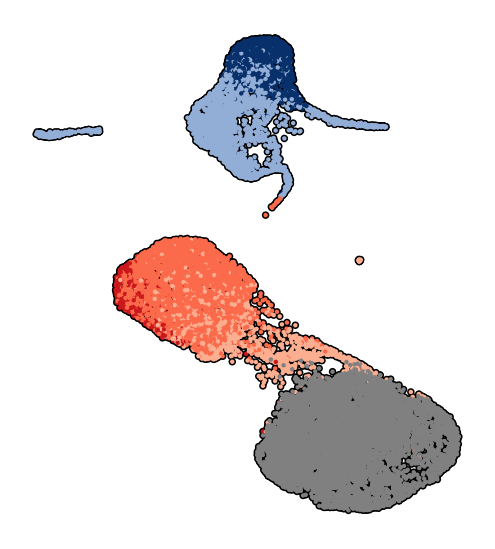

In [4]:
palette = {
    # HSC group – blues
    'HSC'     : '#08306B',
    'GMP'      : '#93AED6',
    'MPP'     : '#93AED6',
    'MEG-ERY' : '#93AED6',
    'CMP'     : '#93AED6',
    'LMPP'    : '#93AED6',#'limegreen',
    'CLP'     : '#93AED6',#'b',

    # reprogram group – reds
    'R1'      : '#FCAE91',
    'R2'      : '#FB6A4A',
    'R3'      : '#CB181D',

    # initial group – neutral grey
    'initial'  : '#808080',
}

plt.rcParams['figure.dpi'] = 150
plt.rcParams['figure.figsize'] = 4, 4.5

sc.pl.umap(
    # adata[adata.obs['filter_pass']], 
    adata,
    color='label', 
    size=18,
    ncols=3,
    alpha=1,
    use_raw=False,
    na_in_legend=False,
    palette=palette,
    add_outline=True,
    outline_color=('k', 'k'),
    frameon=False,
    legend_loc='none',
    wspace=0.5,
    title="",
)

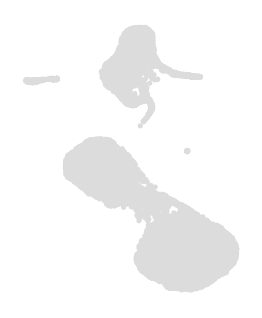

In [5]:
plt.rcParams['figure.dpi']    = 150
plt.rcParams['figure.figsize'] = 2, 2.5

sc.pl.umap(
    adata,
    frameon=False,
    na_color='gainsboro',
    s=25,
)

In [6]:
print(adata.obs['group'].value_counts())
print(adata.obs['subgroup'].value_counts())

group
initial      8464
reprogram    6832
bm_other     3952
target       1506
Name: count, dtype: int64
subgroup
initial        8464
R2             4323
progenitors    2956
R1             1985
HSC            1506
R3              524
CLP             500
LMPP            496
Name: count, dtype: int64


In [7]:
print(adata.obs['cluster_all'].value_counts())

cluster_all
C4    4612
R2    4323
C5    3852
B1    2162
R1    1985
B5    1506
R3     524
B7     500
B2     496
B4     440
B3     302
B6      52
Name: count, dtype: int64


In [8]:
# remove spike-ins from initial
adata.obs['subgroup_clean'] = adata.obs['subgroup'].copy()

adata.obs['subgroup_clean'] = adata.obs['subgroup_clean'].astype(str)

spike_mask = (
    (adata.obs['source'] == 'hsc') &
    (adata.obs['cluster_all'].isin(['C4', 'C5']))
)

print(spike_mask.value_counts())

adata.obs.loc[spike_mask, 'subgroup_clean'] = 'spike-ins'
adata.obs['subgroup_clean'] = adata.obs['subgroup_clean'].astype('category')

adata.obs['subgroup_clean'].value_counts()

False    19246
True      1508
Name: count, dtype: int64


subgroup_clean
initial        6956
R2             4323
progenitors    2956
R1             1985
spike-ins      1508
HSC            1506
R3              524
CLP             500
LMPP            496
Name: count, dtype: int64

In [9]:
# remove spike-ins from initial
adata.obs['group_clean'] = adata.obs['group'].copy()

adata.obs['group_clean'] = adata.obs['group_clean'].astype(str)

spike_mask = (
    (adata.obs['source'] == 'hsc') &
    (adata.obs['cluster_all'].isin(['C4', 'C5']))
)

print(spike_mask.value_counts())

adata.obs.loc[spike_mask, 'group_clean'] = 'spike-ins'
adata.obs['group_clean'] = adata.obs['group_clean'].astype('category')

adata.obs['group_clean'].value_counts()

False    19246
True      1508
Name: count, dtype: int64


group_clean
initial      6956
reprogram    6832
bm_other     3952
spike-ins    1508
target       1506
Name: count, dtype: int64

# Distance

In [10]:
xdata = adata[adata.obs['group_clean'] == 'reprogram', :]
X = xdata.obsm['X_scvi']
print(f"{X.shape=}")

df = xdata.obs.copy()

dist_columns = []

metric = 'euclidean'

for y_label in ['initial', 'target']:
    ydata = adata[adata.obs['group_clean'] == y_label, :]
    Y = ydata.obsm['X_scvi']
    dists = pairwise_distances(X=X, Y=Y, metric=metric)

    column_name = f"{y_label}"
    dist_columns.append(column_name)
    dists = pairwise_distances(X=X, Y=Y, metric=metric)
    df[column_name] = dists.mean(axis=1)

df[dist_columns].head()

X.shape=(6832, 24)


,initial,target
AAACCCAAGGTTACCT-1_hsc,4.435965,4.987195
AAACCCAAGTTGAAGT-1_hsc,5.074771,4.488849
AAACCCACAGGAGGTT-1_hsc,5.725537,6.363568
AAACCCAGTACCTAAC-1_hsc,4.114542,5.140447
AAACCCATCAGGACGA-1_hsc,5.277404,4.957762


In [11]:
# get mean distances for far reference in plot 

X_init = adata[adata.obs['subgroup_clean'] == 'initial'].obsm['X_scvi']
X_target = adata[adata.obs['subgroup_clean'] == 'HSC'].obsm['X_scvi']

# compute all pairwise Euclidean distances (initial × target)
D = pairwise_distances(X_init, X_target, metric=metric)

# take the mean over every entry
mean_pairwise_distance = np.mean(D)

print(f"Mean initial–target {metric} distance:", mean_pairwise_distance)
print("median:", np.median(D))
print("std:", np.std(D))
print("min:", np.min(D))
print("max:", np.max(D))


# get mean distances for close reference in plot 
X_init = adata[adata.obs['subgroup_clean'] == 'progenitors'].obsm['X_scvi']
X_target = adata[adata.obs['subgroup_clean'] == 'HSC'].obsm['X_scvi']

# compute all pairwise Euclidean distances (initial × target)
D = pairwise_distances(X_init, X_target, metric=metric)

# take the mean over every entry
mean_pairwise_distance_close = np.mean(D)

print(f"\nMean progenitor–target {metric} distance:", mean_pairwise_distance_close)
print("median:", np.median(D))
print("std:", np.std(D))
print("min:", np.min(D))
print("max:", np.max(D))

Mean initial–target euclidean distance: 5.4331822
median: 5.3812156
std: 0.6190888
min: 2.605652
max: 10.077658

Mean progenitor–target euclidean distance: 3.761674
median: 3.6788237
std: 1.5335405
min: 0.15456396
max: 10.797794


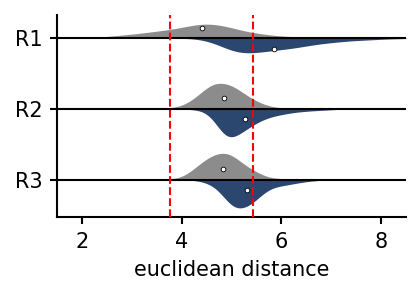

In [12]:
pdf = df.copy()

clusters = ['R1', 'R2', 'R3']

pdf = pdf[pdf['label'].isin(clusters)]
pdf['label'] = pdf['label'].astype(str)

pdf = pd.melt(
    pdf, id_vars='label',
    value_vars=dist_columns
)

# compute means per cluster comparison
means = (
    pdf
    .groupby(['label', 'variable'])['value']
    .mean()
    # .median()
    .reset_index()
)

import matplotlib.ticker as mticker

plt.rcParams['figure.dpi']    = 150
plt.rcParams['figure.figsize'] = 3, 1.75

fig, ax = plt.subplots()

palette = [
    '#808080',
    '#08306B', 
]

sns.violinplot(
    data=pdf,
    y='label',         # was y
    x='value',           # was x
    hue='variable',
    order=clusters,
    inner=None,
    legend=False,
    bw_adjust=1.5,
    common_norm=True,
    linecolor='k',
    palette=palette,
    alpha=0.9,
    linewidth=0,
    split=True,
    zorder=0,
    ax=ax
)


y_positions = {label: i for i, label in enumerate(clusters)}

half_width = 0.15  # controls separation between top/bottom means

for _, row in means.iterrows():
    y = y_positions[row['label']]
    
    if row['variable'] == 'initial':
        y_offset = y - half_width
        color = palette[0]
    else:  # 'target'
        y_offset = y + half_width
        color = palette[1]
    
    ax.scatter(row['value'], y_offset, color='white', s=20, zorder=10, marker='.', linewidth=0.4, edgecolors='k')


# grid
ax.grid(axis='y', lw=1, c='k', zorder=1)

ax.xaxis.set_major_locator(mticker.MaxNLocator(nbins=4))

for spine in ax.spines.values():
    spine.set_linewidth(1)
    
ax.tick_params(axis='both', width=1) 

# relabel
ax.set_xlabel(f'{metric} distance')
ax.set_ylabel('')

ax.axvline(x=mean_pairwise_distance, color='red', ls='--', lw=1, zorder=5)
ax.axvline(x=mean_pairwise_distance_close, color='red', ls='--', lw=1, zorder=5)


plt.xlim([1.5, 8.5])

# sns.move_legend(
#     ax, loc='upper center',
#     ncols=2,
#     title="",
#     bbox_to_anchor=(0.5, 1.2),
#     frameon=False,
    
# )
sns.despine(ax=ax)
plt.show()

In [13]:
means

,label,variable,value
0,R1,initial,4.415325
1,R1,target,5.851653
2,R2,initial,4.838872
3,R2,target,5.272270
4,R3,initial,4.825358
5,R3,target,5.312791


In [14]:
meds = (
    pdf
    .groupby(['label', 'variable'])['value']
    .median()
    .reset_index()
)

meds

,label,variable,value
0,R1,initial,4.430582
1,R1,target,5.711629
2,R2,initial,4.817519
3,R2,target,5.147996
4,R3,initial,4.823293
5,R3,target,5.232013


# gene expression

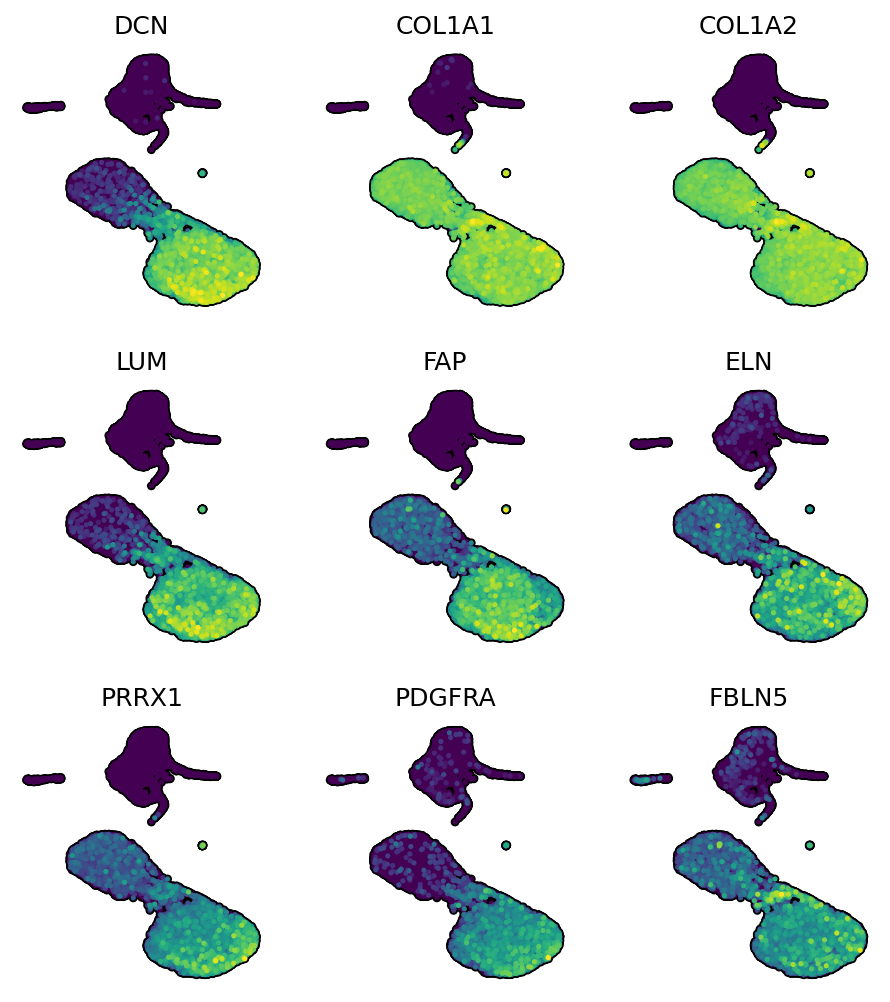

In [16]:
genes_to_plot = [
    'DCN', 'COL1A1', 'COL1A2', 'LUM', 'FAP', 'ELN', 'PRRX1', 'PDGFRA', 'FBLN5',
]

plt.rcParams['figure.dpi'] = 150
plt.rcParams['figure.figsize'] = 2, 2.5

sc.pl.umap(
    adata, 
    color=genes_to_plot,
    size=25,
    ncols=3,
    alpha=1,
    use_raw=False,
    layer='log_norm',
    add_outline=True,
    outline_color=('k', 'k'),
    colorbar_loc=None,
    frameon=False,
    wspace=0.2,
)

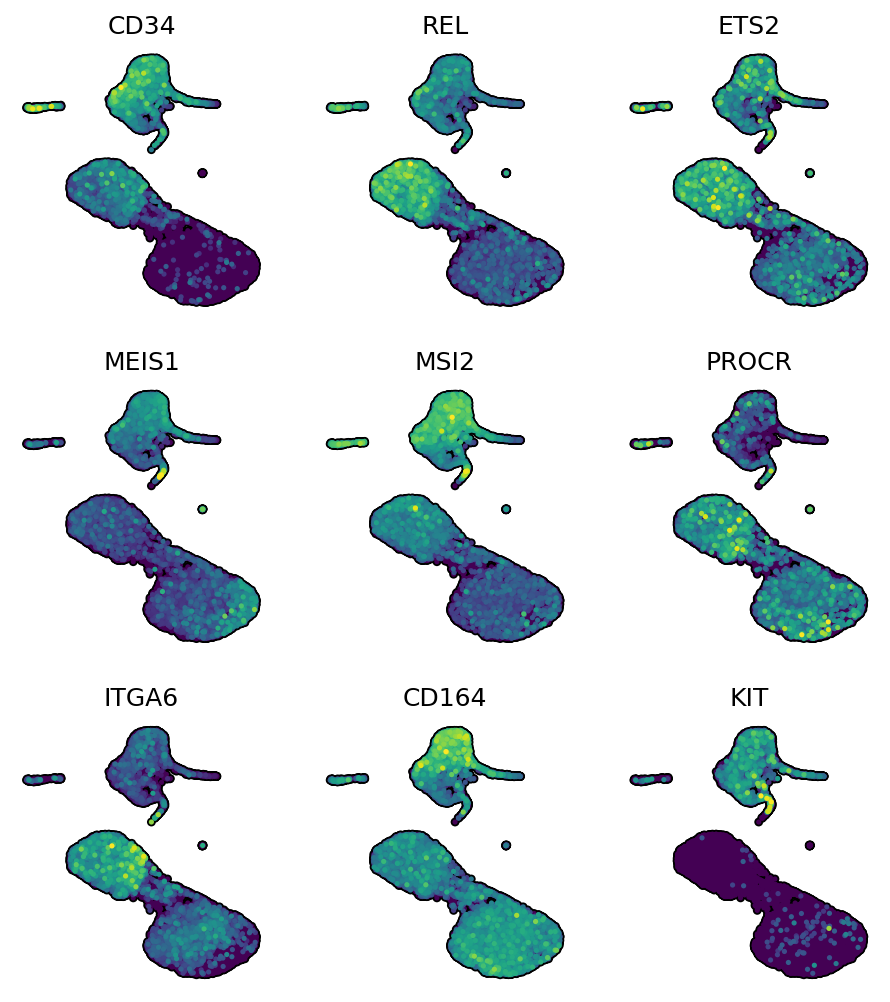

In [17]:
genes_to_plot = [
    'CD34', 'REL', 'ETS2', 'MEIS1', 'MSI2', 'PROCR', 'ITGA6', 'CD164', 'KIT',
]

plt.rcParams['figure.dpi'] = 150
plt.rcParams['figure.figsize'] = 2, 2.5

sc.pl.umap(
    adata, 
    color=genes_to_plot,
    size=25,
    ncols=3,
    alpha=1,
    use_raw=False,
    layer='log_norm',
    add_outline=True,
    outline_color=('k', 'k'),
    colorbar_loc=None,
    frameon=False,
    wspace=0.2,
)

# DEG

In [18]:
# create grouping for DGE
adata.obs['subgroup'] = adata.obs['subgroup'].astype(str)

adata.obs['deg_group'] = np.where(
    adata.obs['subgroup'].isin(['CLP', 'LMPP']),
    'progenitors',
    adata.obs['subgroup']
)

adata.obs['deg_group'].value_counts()

deg_group
initial        8464
R2             4323
progenitors    3952
R1             1985
HSC            1506
R3              524
Name: count, dtype: int64

In [19]:
# remove spike-ins from initial

adata.obs['deg_group_nospike'] = adata.obs['deg_group'].copy()

spike_mask = (
    (adata.obs['source'] == 'hsc') &
    (adata.obs['cluster_all'].isin(['C4', 'C5']))
)

print(spike_mask.value_counts())

adata.obs.loc[spike_mask, 'deg_group_nospike'] = np.nan

adata.obs['deg_group_nospike'].value_counts()

False    19246
True      1508
Name: count, dtype: int64


deg_group_nospike
initial        6956
R2             4323
progenitors    3952
R1             1985
HSC            1506
R3              524
Name: count, dtype: int64

In [20]:
sc.tl.rank_genes_groups(
    adata, 
    groupby='deg_group_nospike',
    method='wilcoxon',
    layer='log_norm',
    use_raw=False,
    pts=True,
    key_added='group_deg',
)

deg = sc.get.rank_genes_groups_df(
    adata, 
    group=None,
    key='group_deg',
    pval_cutoff=0.05,
)

deg.head()

... storing 'subgroup' as categorical
... storing 'deg_group' as categorical
... storing 'deg_group_nospike' as categorical


,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,pct_nz_reference
0,HSC,RPL34,60.857742,1.281515,0.0,0.0,1.000000,0.998545
1,HSC,TPT1,60.283092,1.632625,0.0,0.0,1.000000,0.998441
2,HSC,CRHBP,59.924198,5.468410,0.0,0.0,0.959495,0.079281
3,HSC,HTR1F,59.418045,4.793706,0.0,0.0,0.994688,0.180071
4,HSC,RPS4X,59.123085,2.231575,0.0,0.0,0.999336,0.996571


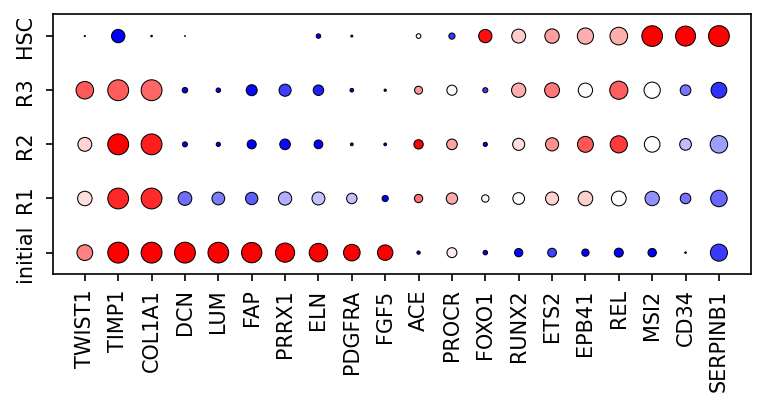

In [21]:
genes = [
    'SERPINB1', 'CD34', 'MSI2', 'REL', 'EPB41', 'ETS2', 'RUNX2', 'FOXO1', 'PROCR', 'ACE',
    'FGF5', 'PDGFRA', 'ELN', 'PRRX1', 'FAP', 'LUM', 'DCN', 'COL1A1', 'TIMP1', 'TWIST1',
]

genes.reverse()

df1 = sc.get.rank_genes_groups_df(
    adata, 
    group=None,
    key='group_deg',
    # pval_cutoff=0.05,
)

groups_of_interest = ['HSC', 'R3', 'R2', 'R1', 'initial']

df1 = df1[df1['group'].isin(groups_of_interest)]

pdf = df1[df1['names'].isin(genes)].copy()

# replace logFC values with 0 for non-DEGs
sig_mask = pdf['pvals_adj'] < 0.05
pdf.loc[~sig_mask, 'logfoldchanges'] = 0


# pdf = pdf.sort_values(by=['group', 'logfoldchanges'], ascending=[True, False])

pdf['names'] = pd.Categorical(pdf['names'], categories=genes, ordered=True)
pdf['group'] = pd.Categorical(pdf['group'], categories=groups_of_interest, ordered=True)

plt.rcParams['figure.dpi'] = 150
plt.rcParams['figure.figsize'] = 6, 2.25

sns.scatterplot(
    data=pdf,
    x='names',
    y='group',
    hue='logfoldchanges',
    size='pct_nz_group',
    sizes=(0, 100),
    legend=False,
    linewidth=0.5,
    ec='k',
    palette='bwr',
    hue_norm=(-2, 2),
)

plt.margins(y=0.1)
plt.gca().tick_params(axis='x', rotation=90, labelsize=10)
plt.ylabel("")
plt.xlabel("")

ax = plt.gca()
for label in ax.get_yticklabels():
    label.set_rotation(90)
    label.set_horizontalalignment('center')
    label.set_verticalalignment('center')
plt.gca().tick_params(axis='y', pad=10)

(np.float64(-0.05500000000000001),
 np.float64(0.05500000000000001),
 np.float64(-0.05500000000000001),
 np.float64(0.05500000000000001))

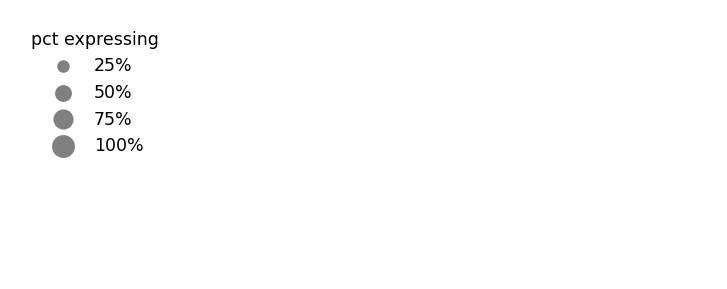

In [22]:
plt.rcParams['figure.dpi'] = 150
sizes = [25, 50, 75, 100]
markers = [plt.scatter([], [], s=s, color='gray') for s in sizes]
labels = [f"{s}%" for s in sizes]

plt.legend(markers, labels, title="pct expressing", scatterpoints=1,
          frameon=False, loc='upper left',
          fontsize='small', title_fontsize='small',
          )

ax = plt.gca()
ax.axis('off')